# Wildfire Exposure Analysis

This notebook identifies which road segments pass through **wildfire susceptible areas** by overlaying a wildfire risk raster onto Serbia's road network.

**Key steps:**
1. Load the road network and wildfire susceptibility raster
2. Visualise the wildfire risk map
3. Assign binary wildfire risk to each road segment
4. Visualise exposed roads (A/B comparison: raster vs road overlay)
5. Summary statistics
6. Save results as ArcGIS layers

> **Note:** The wildfire risk is treated as binary — a road either passes through a susceptible area or it doesn't. The original raster contains classes 1–6, but any non-zero value is considered "at risk".

## Step 1: Setup and Imports

In [81]:
import warnings
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from rasterio.warp import transform_bounds
from shapely.geometry import mapping

warnings.simplefilter(action="ignore", category=FutureWarning)

### Helper functions

In [82]:
# Helper functions

def save_lyrx_layer(gdf, gpkg_path, lyrx_path, layer_name, labels, colors, width_mapping, field, title=None):
    """Save GeoDataFrame to GeoPackage + ArcGIS Pro .lyrx with unique-value symbology."""
    import json as _json

    gdf.to_file(gpkg_path, driver="GPKG", layer=layer_name)
    print(f"Saved GeoPackage → {gpkg_path}")

    try:
        import arcpy
    except ImportError:
        print("arcpy not available — .lyrx skipped. GeoPackage was saved successfully.")
        return

    title = title or layer_name
    gpkg_layer_path = str(gpkg_path.absolute()) + f"/{layer_name}"
    tmp_layer_name = f"tmp_lyr_{layer_name}"
    arcpy.management.MakeFeatureLayer(gpkg_layer_path, tmp_layer_name)
    tmp_lyrx = lyrx_path.with_suffix(".tmp.lyrx")
    arcpy.management.SaveToLayerFile(tmp_layer_name, str(tmp_lyrx), "ABSOLUTE")
    arcpy.management.Delete(tmp_layer_name)

    with open(tmp_lyrx) as f:
        lyrx = _json.load(f)

    def _make_symbol(hex_color, width):
        h = hex_color.lstrip("#")
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return {
            "type": "CIMSymbolReference",
            "symbol": {
                "type": "CIMLineSymbol",
                "symbolLayers": [{
                    "type": "CIMSolidStroke", "enable": True,
                    "capStyle": "Round", "joinStyle": "Round",
                    "width": width,
                    "color": {"type": "CIMRGBColor", "values": [r, g, b, 100]},
                }],
            },
        }

    renderer = {
        "type": "CIMUniqueValueRenderer",
        "defaultLabel": "<all other values>",
        "defaultSymbolPatch": "Default",
        "defaultSymbol": _make_symbol("#cccccc", 0.5),
        "defaultSymbolVisible": False,
        "fields": [field],
        "groups": [{
            "type": "CIMUniqueValueGroup",
            "classes": [
                {
                    "type": "CIMUniqueValueClass",
                    "label": label, "patch": "Default",
                    "symbol": _make_symbol(color, width_mapping.get(label, 1.0)),
                    "values": [{"type": "CIMUniqueValue", "fieldValues": [label]}],
                    "visible": True,
                }
                for label, color in zip(labels, colors)
            ],
            "heading": field,
        }],
        "useDefaultSymbol": False,
    }

    lyrx["layerDefinitions"][0]["renderer"] = renderer
    lyrx["layerDefinitions"][0]["name"] = title

    with open(lyrx_path, "w") as f:
        _json.dump(lyrx, f, indent=2)

    tmp_lyrx.unlink()
    print(f"Saved layer file → {lyrx_path}")

### Define file paths

In [83]:
BASE_DIR = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2")

data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
arcgis_gpkg = arcgis_results / "Geopackages"

# Create output directories if they don't exist
figure_path.mkdir(parents=True, exist_ok=True)
arcgis_results.mkdir(parents=True, exist_ok=True)
arcgis_gpkg.mkdir(parents=True, exist_ok=True)

## Step 2: Load Data

### Road network and country boundary

In [84]:
# Load road network
roads = gpd.read_file(data_path / "DeoniceRSDP-Jul2025..shp")
print(f"Road segments loaded: {len(roads):,}")
print(f"CRS: {roads.crs}")

# Load country outline (for plotting)
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country_plot = world.loc[world.SOV_A3 == 'SRB']
# Clip to Serbia only (remove Kosovo roads)
roads = gpd.clip(roads, country_plot.to_crs(roads.crs))


Road segments loaded: 2,023
CRS: EPSG:4326


## Step 3: Visualise Wildfire Susceptibility

The wildfire risk raster covers Serbia's forested areas. We display it as a binary map — any area with a susceptibility class (values 1–6) is shown in red. The raster is downsampled by a factor of 10 for faster rendering.

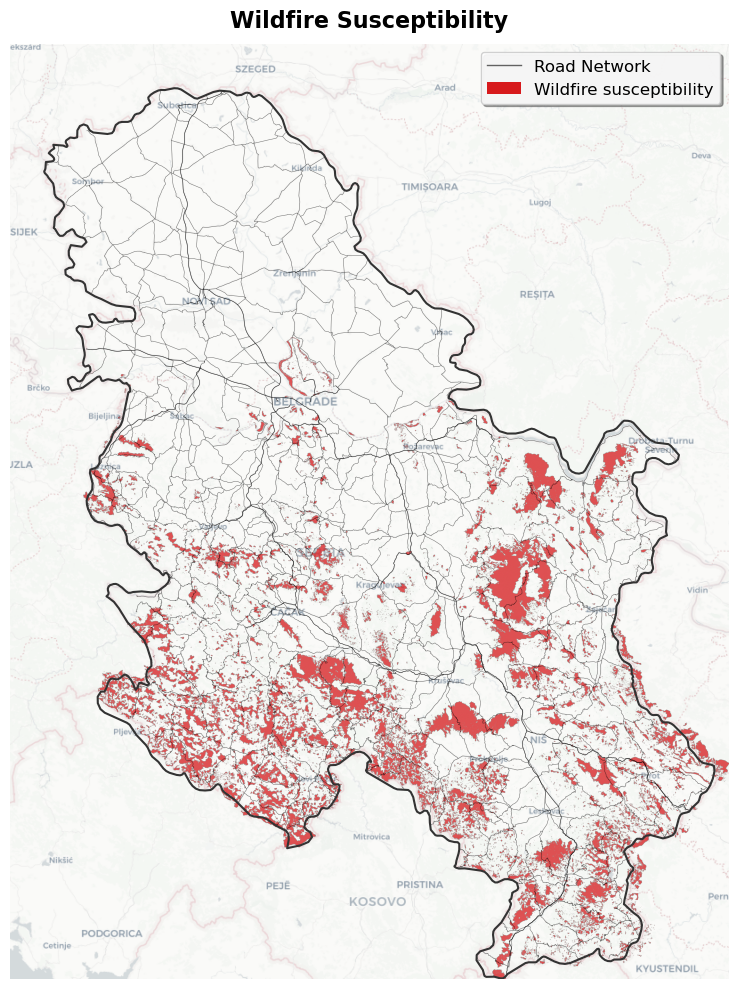

In [85]:
fire_path = data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif"

with rasterio.open(fire_path) as src:
    scale_factor = 10
    out_shape = (1, int(src.height / scale_factor), int(src.width / scale_factor))
    data = src.read(
        1, out_shape=out_shape,
        resampling=Resampling.nearest
    ).astype(float)

    data[data == src.nodata] = np.nan
    fire_bounds = src.bounds
    fire_crs = src.crs
    bounds_mercator = transform_bounds(
        fire_crs, "EPSG:3857",
        fire_bounds.left, fire_bounds.bottom,
        fire_bounds.right, fire_bounds.top
    )

# Binary: any finite value = wildfire risk
binary_data = np.where(np.isfinite(data), 1, 0)

color_array = np.zeros((*binary_data.shape, 4))
color_array[binary_data == 1] = mcolors.to_rgba('#d7191c', alpha=0.75)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

serbia_mercator = country_plot.to_crs(3857)
roads_mercator = roads.to_crs(3857)

ax.imshow(
    color_array,
    extent=[bounds_mercator[0], bounds_mercator[2],
            bounds_mercator[1], bounds_mercator[3]],
    zorder=2, origin='upper'
)

serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                     linewidth=1.5, zorder=4)
roads_mercator.plot(ax=ax, color='black', linewidth=0.4,
                    alpha=0.5, zorder=3)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, attribution=False)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Wildfire Susceptibility", fontsize=16, fontweight='bold', pad=12)

legend_elements = [
    Line2D([0], [0], color='black', linewidth=1, label='Road Network', alpha=0.6),
    Patch(facecolor='#d7191c', edgecolor='none', label='Wildfire susceptibility'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, title_fontsize=14,
          frameon=True, fancybox=True, shadow=True,
          framealpha=0.9, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'wildfire_susc_map.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Assign Wildfire Risk to Roads

For each road segment, we buffer the geometry by 10 meters and check whether any raster pixel within that buffer has a wildfire susceptibility value > 0. This is a binary classification: risk or no risk.

> **Note:** This step iterates over every road segment and can take a few minutes to complete.

In [86]:
def assign_binary_wildfire_risk_to_roads(raster_path, roads_gdf, buffer_meters=10):
    """
    Assign binary wildfire risk to roads:
    1 = wildfire risk (any raster value > 0 within buffer)
    0 = no wildfire risk (only 0 or nodata)
    """
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs
        nodata = src.nodata
        transform = src.transform
        raster_window = rasterio.windows.Window(0, 0, src.width, src.height)

        roads_reproj = roads_gdf.to_crs(raster_crs)
        wildfire_risk = []

        for geom in roads_reproj.geometry:
            try:
                buffered = geom.buffer(buffer_meters)

                bounds = buffered.bounds
                window = rasterio.windows.from_bounds(
                    bounds[0], bounds[1], bounds[2], bounds[3], transform
                ).round_lengths().round_offsets()

                if not rasterio.windows.intersect(window, raster_window):
                    wildfire_risk.append(0)
                    continue

                window = rasterio.windows.intersection(window, raster_window)
                if window.width < 1 or window.height < 1:
                    wildfire_risk.append(0)
                    continue

                data = src.read(1, window=window)
                win_transform = src.window_transform(window)

                mask = geometry_mask(
                    [mapping(buffered)],
                    out_shape=data.shape,
                    transform=win_transform,
                    invert=True
                )

                pixels = data[mask & (data != nodata)]
                wildfire_risk.append(1 if np.any(pixels > 0) else 0)

            except Exception:
                wildfire_risk.append(0)

        result = roads_reproj.copy()
        result["wildfire_susc"] = wildfire_risk
        result = result.to_crs(roads_gdf.crs)
        return result


print("Assigning binary wildfire risk to roads...")
roads_with_risk = assign_binary_wildfire_risk_to_roads(
    fire_path, roads, buffer_meters=10
)

print("\nBinary wildfire risk distribution:")
print(roads_with_risk["wildfire_susc"].value_counts().sort_index())

Assigning binary wildfire risk to roads...

Binary wildfire risk distribution:
wildfire_susc
0    1409
1     419
Name: count, dtype: int64


### Summary statistics

In [87]:
# By segment count
counts = roads_with_risk["wildfire_susc"].value_counts(normalize=True) * 100
print("Percentage of road segments:")
print(f"  No wildfire risk: {counts.get(0, 0):.1f}%")
print(f"  Wildfire risk:    {counts.get(1, 0):.1f}%")

# By road length
roads_metric = roads_with_risk.to_crs(3857)
roads_metric["length_m"] = roads_metric.geometry.length
length_summary = roads_metric.groupby("wildfire_risk")["length_m"].sum()
total_length = length_summary.sum()

print(f"\nPercentage of total road length:")
print(f"  No wildfire risk: {100 * length_summary.get(0, 0) / total_length:.1f}%")
print(f"  Wildfire risk:    {100 * length_summary.get(1, 0) / total_length:.1f}%")
print(f"\nTotal road length: {total_length / 1000:.0f} km")
print(f"Exposed road length: {length_summary.get(1, 0) / 1000:.0f} km")

Percentage of road segments:
  No wildfire risk: 77.1%
  Wildfire risk:    22.9%


<class 'KeyError'>: 'wildfire_risk'

## Step 5: Comparison — Raster vs Road Overlay

Side-by-side view: Panel A shows the raw wildfire susceptibility raster, Panel B shows which road segments are exposed.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), facecolor='white')
fig.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05, wspace=0.0)

serbia_mercator = country_plot.to_crs(3857)
roads_mercator_all = roads.to_crs(3857)
roads_mercator_risk = roads_with_risk.to_crs(3857)

# ── Panel A: Raster ──
ax_a = axes[0]

# Reload downsampled raster for panel A
with rasterio.open(fire_path) as src:
    scale_factor = 10
    out_shape = (1, int(src.height / scale_factor), int(src.width / scale_factor))
    data_a = src.read(1, out_shape=out_shape, resampling=Resampling.nearest).astype(float)
    data_a[data_a == src.nodata] = np.nan
    fire_bounds = src.bounds
    bounds_merc = transform_bounds(src.crs, "EPSG:3857",
                                   fire_bounds.left, fire_bounds.bottom,
                                   fire_bounds.right, fire_bounds.top)

binary_a = np.where(np.isfinite(data_a), 1, 0)
color_a = np.zeros((*binary_a.shape, 4))
color_a[binary_a == 1] = mcolors.to_rgba("#d7191c", alpha=0.75)

ax_a.imshow(color_a,
            extent=[bounds_merc[0], bounds_merc[2], bounds_merc[1], bounds_merc[3]],
            zorder=2, origin="upper")
roads_mercator_all.plot(ax=ax_a, color="black", linewidth=0.4, alpha=0.5, zorder=3)
serbia_mercator.plot(ax=ax_a, facecolor="none", edgecolor="#333333", linewidth=1.5, zorder=4)
cx.add_basemap(ax=ax_a, source=cx.providers.CartoDB.Positron, attribution=False)
ax_a.set_aspect("equal")
ax_a.axis("off")

legend_a = [
    Line2D([0], [0], color="black", linewidth=1, label="Road Network", alpha=0.6),
    Patch(facecolor="#d7191c", edgecolor="none", label="Wildfire susceptibility"),
]
ax_a.legend(handles=legend_a, loc="upper right", fontsize=10,
            frameon=True, fancybox=True, shadow=True,
            framealpha=0.9, facecolor="white", edgecolor="#cccccc")

# ── Panel B: Roads ──
ax_b = axes[1]

roads_mercator_all.plot(ax=ax_b, color="black", linewidth=0.4, alpha=0.5, zorder=2)

exposed = roads_mercator_risk[roads_mercator_risk["wildfire_risk"] == 1]
if not exposed.empty:
    exposed.plot(ax=ax_b, color="#d7191c", linewidth=1.0, alpha=0.85, zorder=3)

serbia_mercator.plot(ax=ax_b, facecolor="none", edgecolor="#333333", linewidth=1.5, zorder=4)
cx.add_basemap(ax=ax_b, source=cx.providers.CartoDB.Positron, attribution=False)
ax_b.set_aspect("equal")
ax_b.axis("off")

legend_b = [
    Line2D([0], [0], color="black", linewidth=1, label="Road Network", alpha=0.6),
    Patch(facecolor="#d7191c", edgecolor="none",
          label="Roads running through\nwildfire susceptible areas"),
]
ax_b.legend(handles=legend_b, loc="upper right", fontsize=10,
            frameon=True, fancybox=True, shadow=True,
            framealpha=0.9, facecolor="white", edgecolor="#cccccc")

# Panel labels
for ax, label in zip(axes, ["A", "B"]):
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=16,
            fontweight="bold", verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(figure_path / 'wildfire_susceptibility_AB.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 6: Save Results as ArcGIS Layers

The results are saved as a GeoPackage and ArcGIS Pro layer file. Open the `.lyrx` file in ArcGIS Pro to see the results on your map.

In [ ]:
roads_with_risk["wildfire_class"] = roads_with_risk["wildfire_risk"].map({
    0: "No Susceptibility",
    1: "Wildfire Susceptibility",
})

save_lyrx_layer(
    gdf=roads_with_risk,
    gpkg_path=arcgis_gpkg / "wildfire_risk_roads.gpkg",
    lyrx_path=arcgis_results / "wildfire_risk_roads.lyrx",
    layer_name="wildfire_susceptibility_roads",
    labels=["No Susceptibility", "Wildfire Susceptibility"],
    colors=["#000000", "#d7191c"],
    width_mapping={"No Susceptibility": 0.4, "Wildfire Susceptibility": 1.0},
    field="wildfire_class",
    title="Wildfire Susceptibility on Roads",
)

print("\n✅ Done! Open 'wildfire_risk_roads.lyrx' in ArcGIS Pro to view the results.")